## **UNIVERSITY OF THE UNITED STATES INTERNATIONAL UNIVERSITY – AFRICA (USIU-Africa)**

### **School of Science and Technology**
#### **Department of Data Science and Analytics**

**Course / Semester:** US Semester  
**Lecturer:** Asst. Prof. Edward Ombui, Ph.D  


**Student Name:** Ambachow Kahsay  
**Student ID:** 670550  

**Submission Type:** Text Preprocessing Assignment  
**Dataset:** OmbuiHSRaw.csv  

**Date:** May 2026

## **Hate Speech Dataset Preprocessing**

**Import Required Libraries**

In [171]:
# BASIC LIBRARIES
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# VISUALIZATION
from wordcloud import WordCloud
import seaborn as sns

# NLP LIBRARIES
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# DOWNLOAD REQUIRED NLTK DATA

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# INITIALIZE NLP TOOLS
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


- The **object** data type indicates that the column contains textual data represented as strings.


**1. Load and Explore the Dataset**

In [172]:
from google.colab import files
uploaded = files.upload()

Saving OmbuiHSRaw.csv to OmbuiHSRaw (2).csv


In [173]:
# Load dataset safely
file_name = list(uploaded.keys())[0]

df = pd.read_csv(
    file_name,
    sep=';',
    skiprows=1,
    header=None,
    on_bad_lines='skip',
    encoding='utf-8'
)


In [174]:
# Inspect raw structure
print(df.head())
print(df.shape)
print(df.columns)

                                                   0
0  ;2017-10-18 11:04;0;0;"That #ShangweVedio shou...
1  ;2017-10-18 09:15;0;1;"they wrote letters to i...
2  ;2017-10-18 09:06;0;2;"Akombe was a nasa mole ...
3  ;2017-10-04 12:24;0;0;"@paulinenjoroge @OleItu...
4  ;2017-09-25 20:20;0;0;"#akombemustgo";;;#akomb...
(155163, 1)
Index([0], dtype='int64')


In [175]:
df_text = pd.DataFrame(data, columns=["text"])
print(df_text.head())
print(df_text.shape)

                                                text
0  That #ShangweVedio should be replaced. Where d...
1  they wrote letters to iebc their bloggers tren...
2  Akombe was a nasa mole   Jubilee never wanted ...
3  @paulinenjoroge @OleItumbi @JubileePartyK @Tea...
4                                    #akombemustgo""
(20001, 1)


### **About the Data**

- The dataset contains **20,001 tweets**.
- There are **no missing values** in the text column.
- The dataset consists of a single text feature (`text`) with data type `object`.
- Political discussions, hashtags, and public figures are prominent in the tweets.


### **2. Data Cleaning**

#### **2.1 Missing Values**

In [176]:
print("\nMissing Values:")
print(df_text.isnull().sum())


Missing Values:
text    0
dtype: int64



- The dataset contains **no missing values** in the tweet column.


#### **2.2 Duplicate Values**

In [177]:
df_text.columns

Index(['text'], dtype='object')

In [178]:
# Count of duplicate tweets
duplicates = len(df_text) - df_text['text'].nunique()
print(f"\n3. Duplicate tweets: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")


3. Duplicate tweets: 1,051 (0.68%)


In [179]:
print(f"Initial count: {len(df_text)}")

Initial count: 20001


In [180]:
#. Remove duplicates
df = df_text.drop_duplicates().reset_index(drop=True)
print(f"After removing duplicates: {len(df)}")

After removing duplicates: 18950


### **2.3 Preprocessing Functions**

- lets build a pipeline that cleans Twitter data by removing noise (URLs, mentions, hashtags, stopwords) across English, Kiswahili, and Twitter-specific terms.

- Lemmatization was applied before stopword removal to ensure linguistic normalization prior to filtering. Both raw-cleaned tokens and normalized lemmas were retained for comparative analysis.

- Lemmatization is applied to English words to reduce them to base forms, but it is not effective for Kiswahili because the WordNet lemmatizer only supports English and lacks morphological rules for Kiswahili.

**Lemmatization for Kswahili**
- NLTK / WordNet
WordNetLemmatizer only works for English.
It does not understand Kiswahili grammar or roots.

In [181]:
# Check Stemmizationtion
lemmatizer.lemmatize("wanasiasa")

'wanasiasa'

- **Wrangle Function**

In [182]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

twitter_noise = {
    "rt", "co", "https", "http", "www",
    "t", "amp", "com","us", "one", "like", "know",
    "get", "would", "rt","pic", "amp","twitter"
}

swahili_stopwords = {
    "na", "ya", "wa", "kwa", "ni", "katika",
    "hiyo", "hili", "huyu", "hizo", "za", "la", "ku", "ili"
}

political_noise_words = {
    "think", "know", "like", "us", "one",
    "get", "would", "say", "said", "now",
    "even", "make", "people", "status",
    "also", "really", "just", "still",
    "thing", "things", "going", "go",
    "way", "see", "seen", "done",
    "come", "came", "take", "took",
    "want", "needs", "need", "much",
    "many", "less","time", "more"
}

stop_words = stop_words.union(twitter_noise).union(swahili_stopwords).union(political_noise_words)

# TYPO MAP
COMMON_TYPO_MAP = {
    "u": "you",
    "r": "are",
    "bcoz": "because",
    "coz": "because",
    "ppl": "people",
    "wat": "what",
    "cnt": "cant",
    "electn": "election",
    "hatespech": "hate speech",
}


def preprocess(text):

    # Lowercase
    text = text.lower()

    # Remove noise
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    tokens = text.split()

    # Fix elongated words
    tokens = [re.sub(r'(.)\1+', r'\1\1', w) for w in tokens]

    # Typo + slang normalization
    tokens = [COMMON_TYPO_MAP.get(w, w) for w in tokens]

    #  Lemmatization FIRST (better linguistic normalization)
    lemmas = [lemmatizer.lemmatize(w) for w in tokens]

    # Stopword removal (on lemmas = cleaner representation)
    lemmas = [w for w in lemmas if w not in stop_words and len(w) > 1]

    # clean raw tokens consistently
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]

    return " ".join(tokens), " ".join(lemmas)

In [183]:
# Process a sample to ensure speed and visibility
sample_df = df.sample(n=min(15000, len(df)), random_state=42).copy()
results = sample_df['text'].apply(preprocess)
sample_df['cleaned'], sample_df['lemmatized'] = zip(*results)

### **3. EDA**

#### **3.1 Summary statistics**

In [184]:
print(f"Total Unique Tweets after dropping duplicates: {len(df)}")
print(f"Sample size processed: {len(sample_df)}")
print(f"Top 5 common words: {common_words[:5]}")

sample_df.head().to_csv('sample_preprocessed.csv')

Total Unique Tweets after dropping duplicates: 18950
Sample size processed: 15000
Top 5 common words: [('kikuyus', 3356), ('luos', 2725), ('chase', 1853), ('arrestkimaningunjiri', 1324), ('kenyans', 1137)]


#### **3.2 Visualizations - Wordcloud**

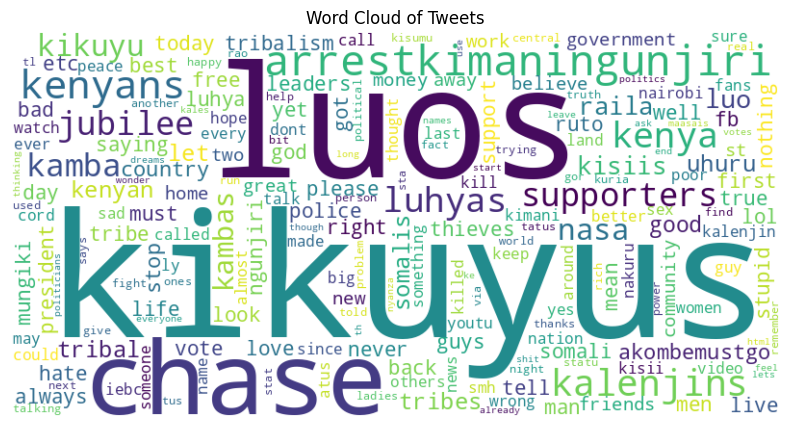

In [185]:
all_words = " ".join(sample_df['cleaned']).split()
word_counts = Counter(all_words)
common_words = word_counts.most_common(20)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Tweets')
plt.show()

- **Histogram- Top 20 Most Frequent Words**

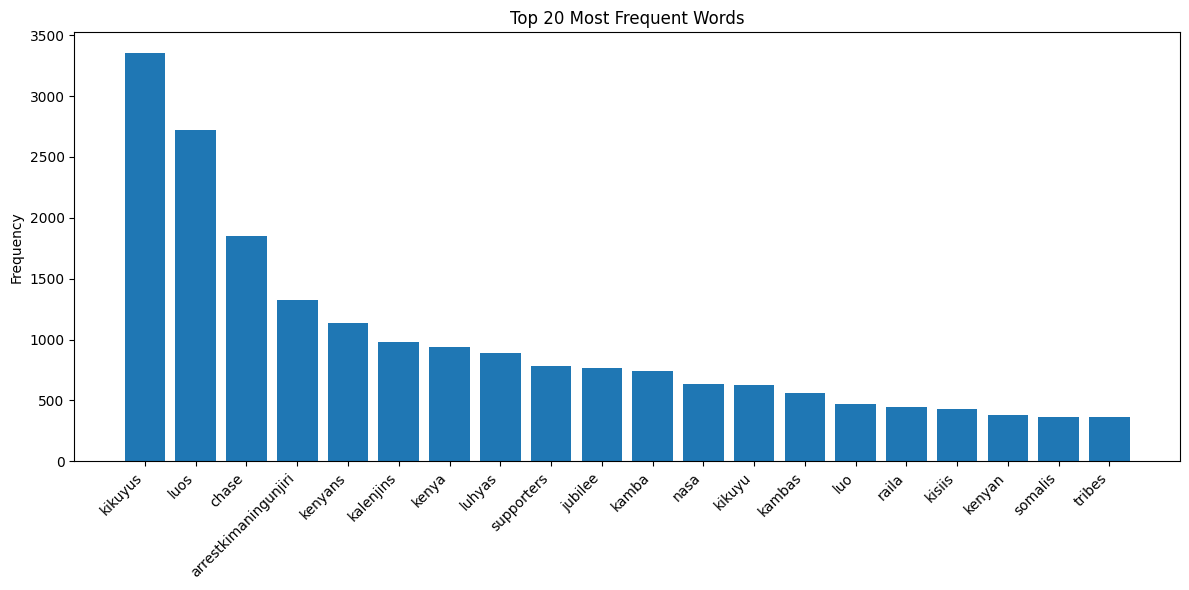

In [186]:
# Bar graph
words, counts = zip(*common_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.tight_layout()

plt.show()

- The dataset contains **18,950** unique tweets after cleaning and a **15,000**-tweet sample for analysis.
- Tweets are mainly focused on **political discussions in Kenya**.
Frequent terms include **ethnic and political references such as kikuyus, luos, kenyans, and arrestkimaningunjiri**.
- Visualizations (word cloud and frequency plots) show dominance of political figures and ethnic group mentions.
- The dataset reflects a highly politicized and identity-driven online discourse.